# Statistical Properties of Simulated Spike Trains

In [105]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: AELIF Neuron with Noise

### 1. Simulation of an AELIF neuron with the following parameters:

Use a timestep, **$dt$, of 0.01 ms** and simulate a duration
of 100 s. Set the input current, **$I_{app}$**, to have a mean of zero but with a
different value on each time step selected from the normal distribution
with a **standard deviation of $\sigma/\sqrt{dt}$**.

In [106]:
dt                 = 0.01e-3            # s
mean               = 0.0
sigma              = 50e-12             # A.s^{0.5}
standard_deviation = sigma / np.sqrt(dt)
size               = int(10 / dt)+1     # number of time steps for 100 seconds

In [107]:
seed_a = 321
data_a = np.load(f'data/tut_3_2/aelif_data_3_2_{seed_a}.npz') # Load the data from the .npz file
t = data_a['t']                                   # Time vector
I_app = data_a['I']                               # Input current

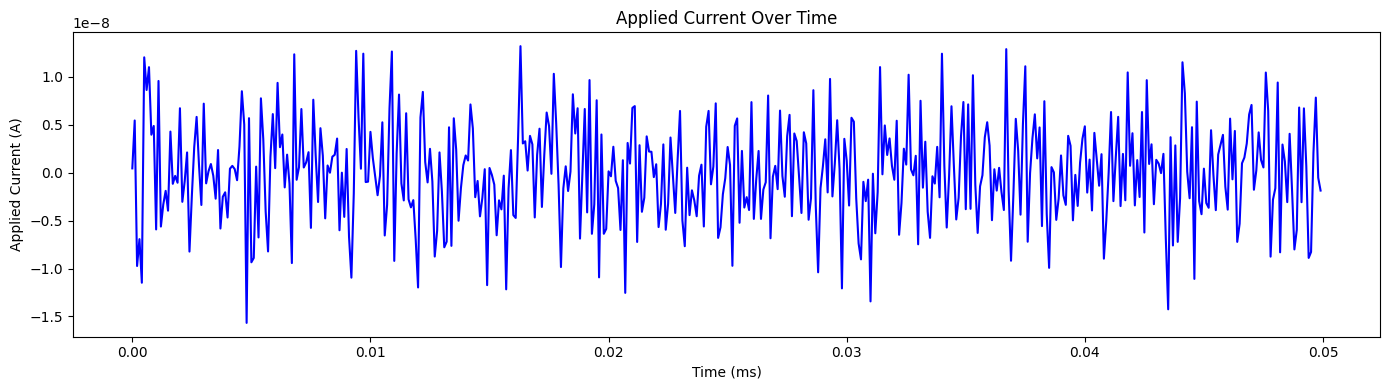

In [108]:
plt.figure(figsize=(14, 4))
plt.plot(t[:500], I_app[:500], marker='', markersize=2.5, linewidth=1.5, color='blue')
plt.xlabel('Time (ms)')
plt.ylabel('Applied Current (A)')
plt.title('Applied Current Over Time')
plt.tight_layout()
plt.savefig(f'../figs/fig_3_2_{seed_a}_current.png', dpi=300)
plt.show()

#### a. Record the spike times and the set of interspike intervals (ISIs) by taking the difference between the spike times.
Initially set $\sigma = 50 pA.s^{0.5} = 0.05 nA.s^{0.5}$
(the exponent of 0.5 in the time units is
canceled when divided by $\sqrt{dt}$
).

In [109]:
spikes = data_a['spikes']

In [110]:
spike_times = np.where(spikes)[0] * dt  # Convert spike index to time (s) of spike occurrence

In [111]:
isi = np.diff(spike_times) # Inter-spike intervals (ISI) in seconds

##### i. Plot the histogram of ISIs 
(use histogram with 25 bins forthe values of ISI).

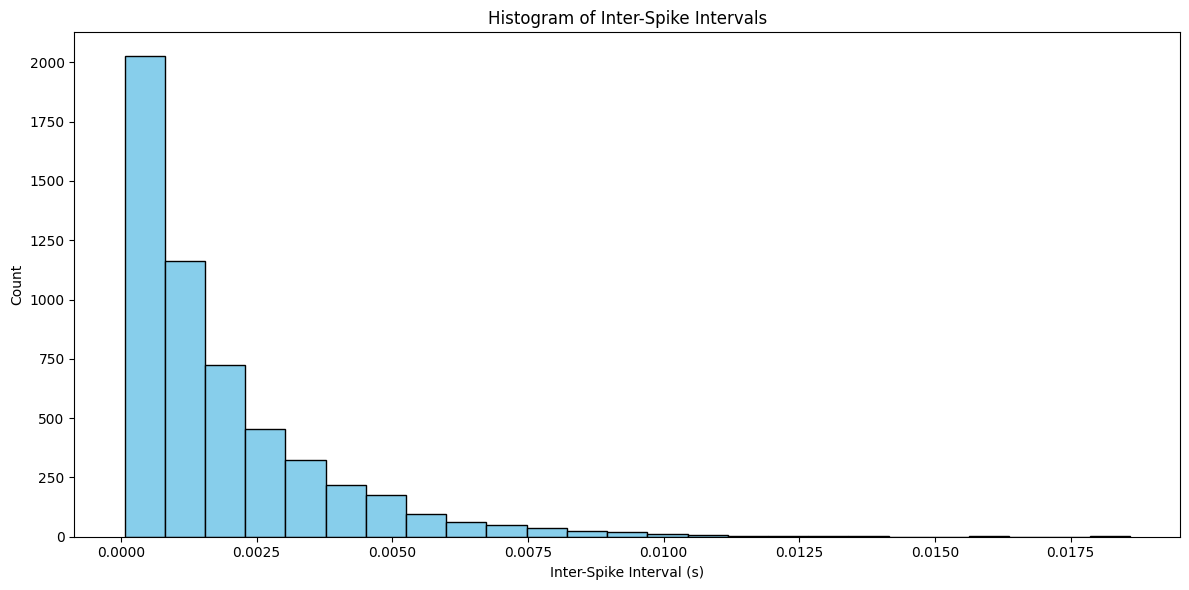

In [112]:
# plot histogram of ISI
plt.figure(figsize=(12, 6))
plt.hist(isi, bins=25, color='skyblue', edgecolor='black')
plt.xlabel('Inter-Spike Interval (s)')
plt.ylabel('Count')
plt.title('Histogram of Inter-Spike Intervals')
plt.tight_layout()
plt.savefig(f'../figs/fig_3_2_{seed_a}_isi_histogram.png', dpi=300)
plt.show()

##### ii. Calculate the CV of the ISIs as the standard deviation divided by the mean.

In [113]:
isi_mean = np.mean(isi)
isi_std = np.std(isi)
cv = isi_std / isi_mean

In [114]:
print(cv)

1.0226900419105336


Poisson-like irregular firing!

##### iii. Calculate the number of spikes in each consecutive 100 ms window.
Calculate the variance and mean of these numbers
(you can use in-built functions) and use these results to
calculate the Fano factor.

In [115]:
window_size = 100e-3 # 100 ms

In [116]:
def fano_factor(t, spikes, window_size):

    dt = t[1] - t[0]

    # número de pontos por janela
    samples_per_window = int(window_size / dt)

    # número máximo de janelas completas
    num_windows = len(spikes) // samples_per_window

    # descarta sobra no final
    trimmed_spikes = spikes[:num_windows * samples_per_window]

    # reorganiza em matriz:
    # cada linha = uma janela temporal
    spike_matrix = trimmed_spikes.reshape(
        num_windows,
        samples_per_window
    )

    # conta spikes por janela
    spike_counts = np.sum(spike_matrix, axis=1)

    # Fano factor
    return np.var(spike_counts) / np.mean(spike_counts)

In [117]:
f = fano_factor(t,spikes, window_size)
print(f)

0.9447697575421061


#### iv. Repeat iii, but use a loop that allows the window size for spike-counting to range from 10 ms up to 1 s. 
Plot Fano factor
against window size.

In [118]:
def fano_factor_per_window(t,spikes):

    windows = np.arange(10e-3, 1, 1e-3) # windows ranging from 10 ms to 1 s
    fano_factors = []
    std = []

    for window in windows:

        ff = fano_factor(t,spikes, window)
        fano_factors.append(ff)
        std.append(np.std(fano_factors))

    std = np.array(std)
    fano_factors = np.array(fano_factors)
    return fano_factors, std

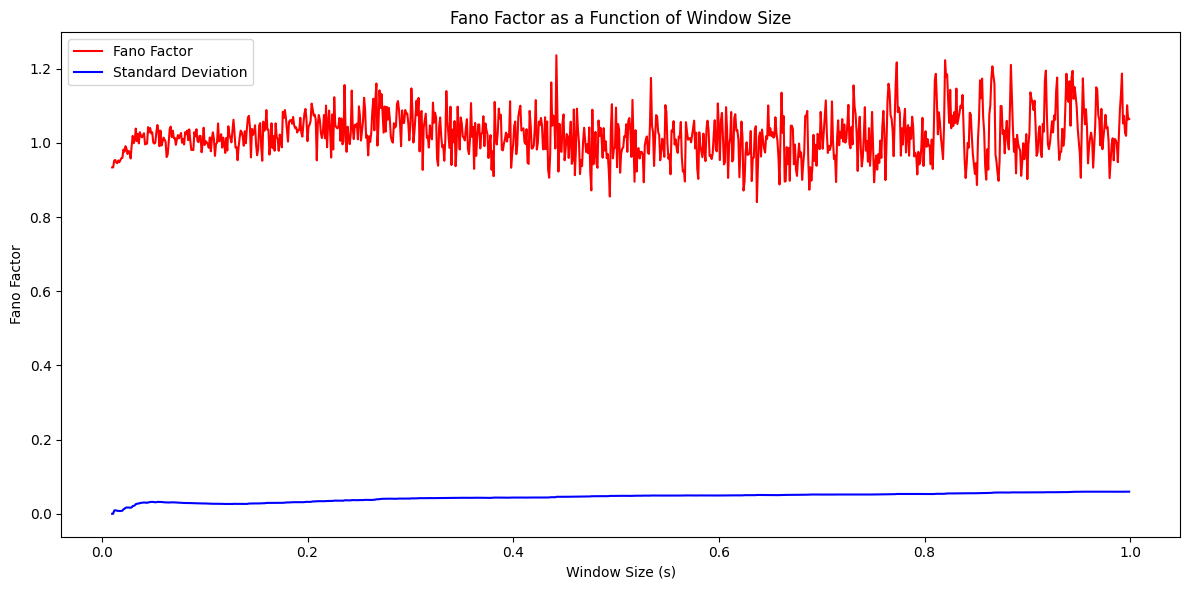

In [119]:
fano_factors, std = fano_factor_per_window(t,spikes)
plt.figure(figsize=(12, 6))
plt.plot(np.arange(10e-3, 1, 1e-3), fano_factors, marker='', linestyle='-', color='red', label='Fano Factor')
plt.plot(np.arange(10e-3, 1, 1e-3), std, marker='', linestyle='-', color='blue', label='Standard Deviation')
plt.xlabel('Window Size (s)')
plt.ylabel('Fano Factor')
plt.title('Fano Factor as a Function of Window Size')
plt.legend()
plt.tight_layout()
plt.savefig(f'../figs/fig_3_2_{seed_a}_fano_factor.png', dpi=300)
plt.show()

### b. Repeat all of the steps of 1a but with AELIF parameter $b=1$ nA.
Explain any differences in your results from 1a and comment on any
dependence on the time-window of the Fano factor in iv.

In [120]:
seed_b = 322
data_b = np.load(f'data/tut_3_2/aelif_data_3_2_{seed_b}.npz') # Load the data from the .npz file
spikes_b = data_b['spikes'] # Spike times for the second dataset

In [121]:
spike_times_b = np.where(spikes_b)[0] * dt  # Convert spike index to time (s) of spike occurrence
isi_b = np.diff(spike_times_b) # Inter-spike intervals (ISI) in seconds

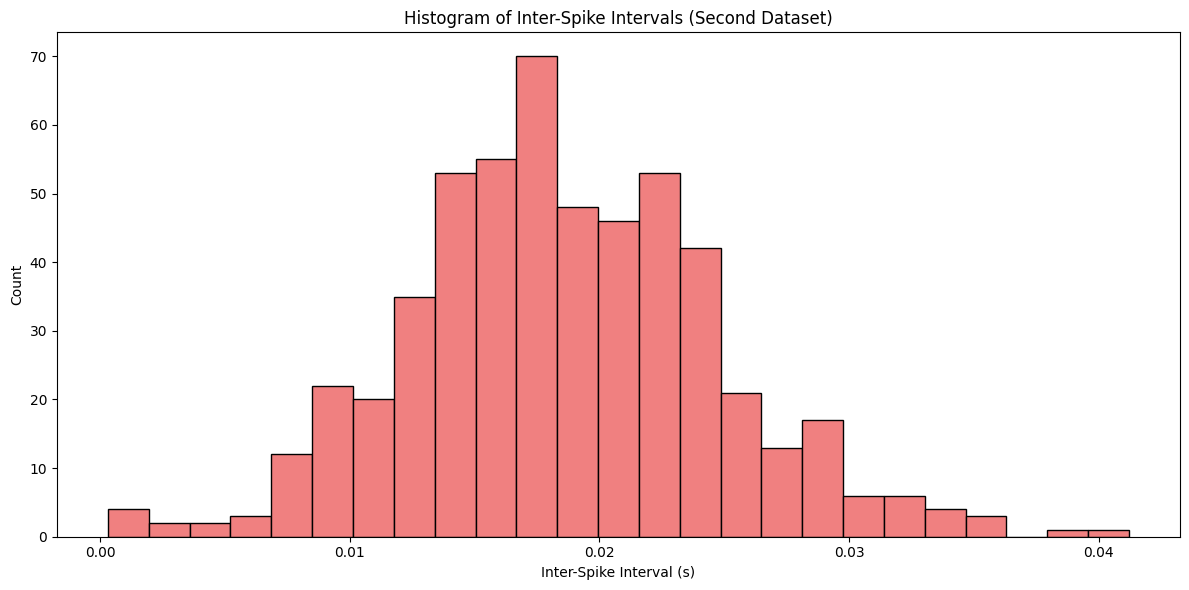

In [122]:
# Plot ISI histogram for the second dataset
plt.figure(figsize=(12, 6))
plt.hist(isi_b, bins=25, color='lightcoral', edgecolor='black')
plt.xlabel('Inter-Spike Interval (s)')
plt.ylabel('Count')
plt.title('Histogram of Inter-Spike Intervals (Second Dataset)')
plt.tight_layout()
plt.savefig(f'../figs/fig_3_2_{seed_b}_isi_histogram.png', dpi=300)
plt.show()

In [123]:
isi_b_mean = np.mean(isi_b)
isi_b_std = np.std(isi_b)
cv_b = isi_b_std / isi_b_mean
print(cv_b)

0.33495359352374504


No longer a Poisson Process!

In [124]:
window_size = 100e-3 # 100 ms
f_b = fano_factor(t,spikes_b, window_size)
print(f_b)

0.4933333333333331


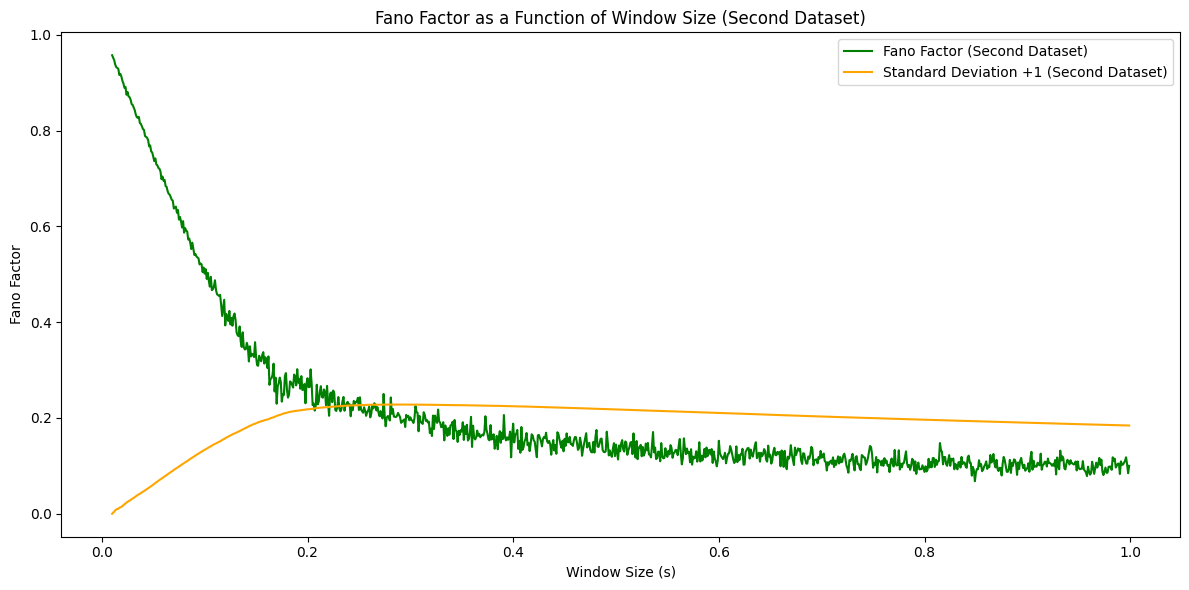

In [125]:
fano_factors_b, std_b = fano_factor_per_window(t,spikes_b)
plt.figure(figsize=(12, 6))
plt.plot(np.arange(10e-3, 1, 1e-3), fano_factors_b, marker='', linestyle='-', color='green', label='Fano Factor (Second Dataset)')
plt.plot(np.arange(10e-3, 1, 1e-3), std_b, marker='', linestyle='-', color='orange', label='Standard Deviation +1 (Second Dataset)')
plt.xlabel('Window Size (s)')
plt.ylabel('Fano Factor')
plt.title('Fano Factor as a Function of Window Size (Second Dataset)')
plt.legend()
plt.tight_layout()
plt.savefig(f'../figs/fig_3_2_{seed_b}_fano_factor.png', dpi=300)
plt.show()

#### c. Repeat steps i–iii of 1a with AELIF parameter $b=0$ nA, while reducing the noise to set $\sigma = 20 pA.s^{0.5}$.

##### **$I_{app}$**:

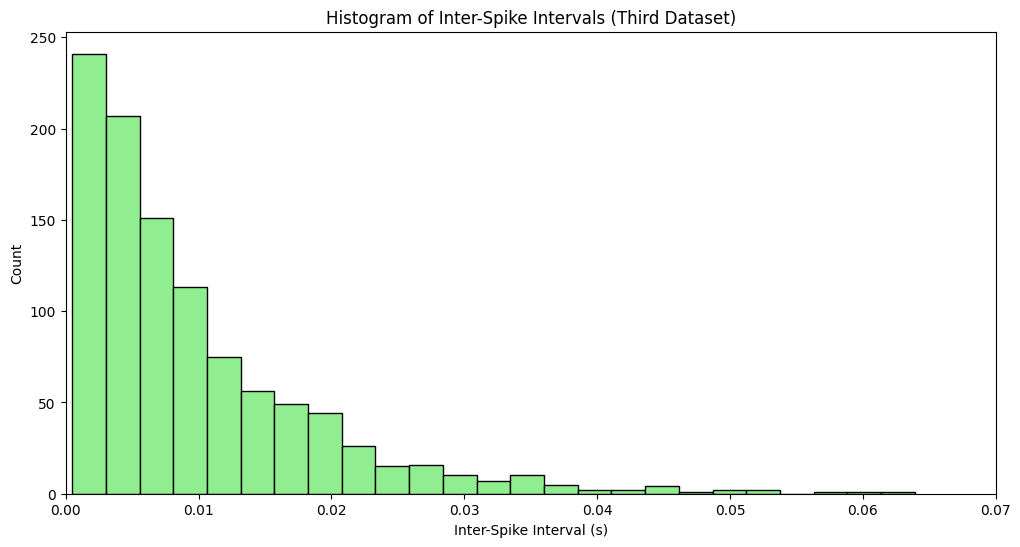

0.9445726363113021
0.8793051823416507


In [126]:
seed_c0 = 323
data_c0 = np.load(f'data/tut_3_2/aelif_data_3_2_{seed_c0}.npz') # Load the data from the .npz file
spikes_c0 = data_c0['spikes'] # Spike times for the third dataset
spike_times_c0 = np.where(spikes_c0)[0] * dt  # Convert spike index to time (s) of spike occurrence
isi_c0 = np.diff(spike_times_c0) # Inter-spike intervals (ISI) in seconds

# Plot ISI histogram for the third dataset
plt.figure(figsize=(12, 6))
plt.hist(isi_c0, bins=25, color='lightgreen', edgecolor='black')
plt.xlabel('Inter-Spike Interval (s)')
plt.ylabel('Count')
plt.title('Histogram of Inter-Spike Intervals (Third Dataset)')
plt.xlim(0, 0.07)
plt.show()

isi_c0_mean = np.mean(isi_c0)
isi_c0_std = np.std(isi_c0)
cv_c0 = isi_c0_std / isi_c0_mean
print(cv_c0)

f_c0 = fano_factor(t,spikes_c0, window_size)
print(f_c0)

##### **$I_{app} + 0.1nA$**:

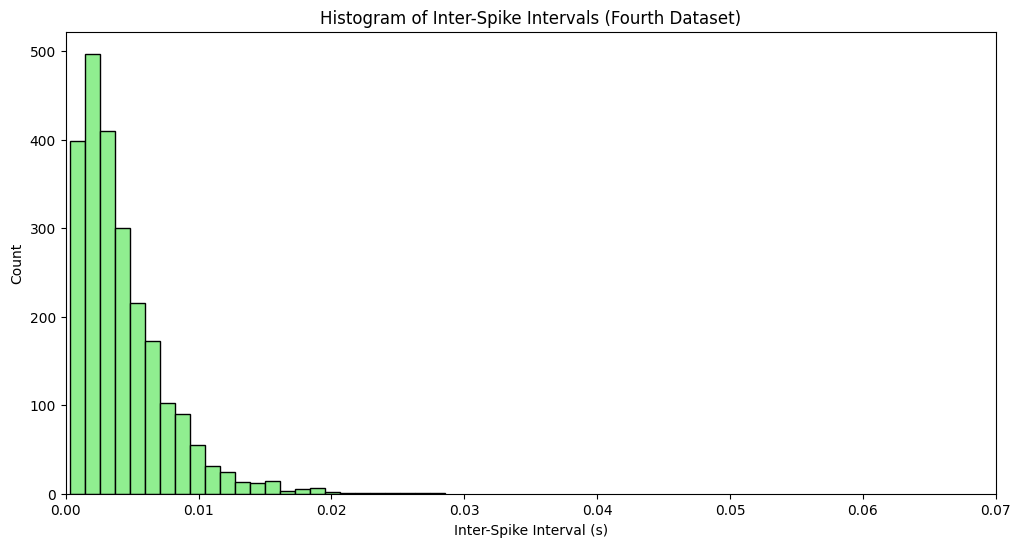

0.7896316776999959
0.5909788045782111


In [127]:
seed_c1 = 324
data_c1 = np.load(f'data/tut_3_2/aelif_data_3_2_{seed_c1}.npz') # Load the data from the .npz file
I_app_c1 = data_c1['I'] # Input current for the fourth dataset
spikes_c1 = data_c1['spikes'] # Spike times for the fourth dataset
spike_times_c1 = np.where(spikes_c1)[0] * dt  # Convert spike index to time (s) of spike occurrence
isi_c1 = np.diff(spike_times_c1) # Inter-spike intervals (ISI) in seconds

# Plot ISI histogram for the fourth dataset
plt.figure(figsize=(12, 6))
plt.hist(isi_c1, bins=25, color='lightgreen', edgecolor='black')
plt.xlabel('Inter-Spike Interval (s)')
plt.ylabel('Count')
plt.title('Histogram of Inter-Spike Intervals (Fourth Dataset)')
plt.xlim(0, 0.07)
plt.show()

isi_c1_mean = np.mean(isi_c1)
isi_c1_std = np.std(isi_c1)
cv_c1 = isi_c1_std / isi_c1_mean
print(cv_c1)

f_c1 = fano_factor(t,spikes_c1, window_size)
print(f_c1)

##### **$I_{app} + 0.2nA$**:

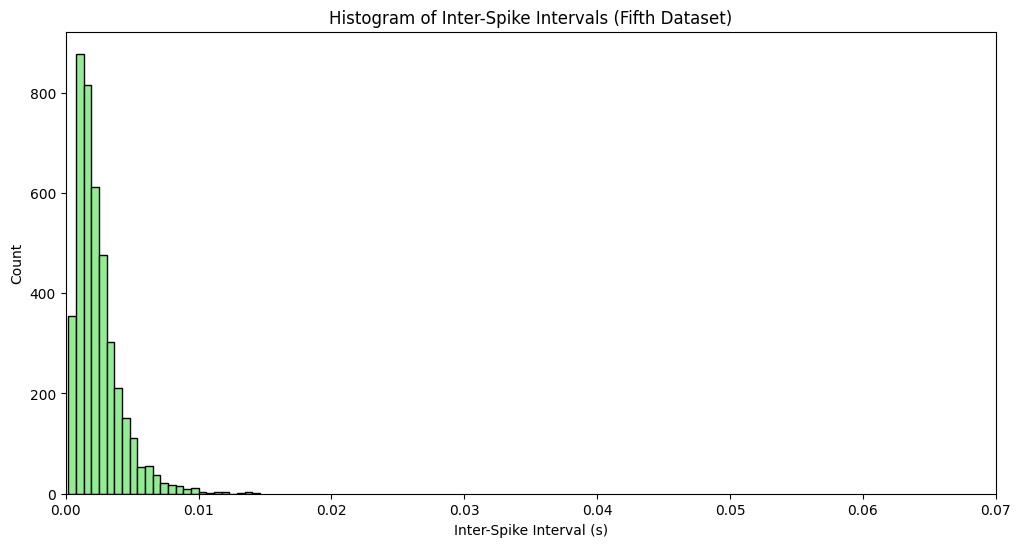

0.7078253199174831
0.5185202312138727


In [128]:
seed_c2 = 325
data_c2 = np.load(f'data/tut_3_2/aelif_data_3_2_{seed_c2}.npz') # Load the data from the .npz file
I_app_c2 = data_c2['I'] # Input current for the fifth dataset
spikes_c2 = data_c2['spikes'] # Spike times for the fifth dataset
spike_times_c2 = np.where(spikes_c2)[0] * dt  # Convert spike index to time (s) of spike occurrence
isi_c2 = np.diff(spike_times_c2) # Inter-spike intervals (ISI) in seconds

# Plot ISI histogram for the fifth dataset
plt.figure(figsize=(12, 6))
plt.hist(isi_c2, bins=25, color='lightgreen', edgecolor='black')
plt.xlabel('Inter-Spike Interval (s)')
plt.ylabel('Count')
plt.title('Histogram of Inter-Spike Intervals (Fifth Dataset)')
plt.xlim(0, 0.07)
plt.show()

isi_c2_mean = np.mean(isi_c2)
isi_c2_std = np.std(isi_c2)
cv_c2 = isi_c2_std / isi_c2_mean
print(cv_c2)

f_c2 = fano_factor(t,spikes_c2, window_size)
print(f_c2)